# 03 - Comparación de los datos de Algeciras y Albacete
Una vez realizados los análisis exploratorios de datos, se pudo comprobar que los conjuntos de datos son muy similares, con diferencias en los nombres de las columnas, así como la escala de las variables de puntuación, o la diferencia en tipos de diversidad, principalmente.

En este Notebook se comparan los conjuntos de datos limpios de Algeciras y Albacete (data/interim), con el objetivo de homogeneizar las columnas de ambos.

Los objetivos principales son:
* Comparar la estructura de los dos conjuntos de datos (filas, columnas y tipos).
* Identificar qué columnas de cada ciudad son equivalentes, y cuáles solo existen en alguna de ellas.
* Comparar las categorías de las variables categóricas (tipología y propuesta de actuación) y la variable de presupuesto.
* Comparar las puntuaciones de accesibilidad (escala, dimensiones y tipos de diversidad).

## Carga de datos

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re
import textwrap

from urban_accessibility_ml.config import (
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
)

df_alg = pd.read_csv(INTERIM_DATA_DIR / "algeciras" / "algeciras_streets_cleaned.csv")
df_alb = pd.read_csv(INTERIM_DATA_DIR / "albacete" / "albacete_streets_cleaned.csv")

2026-10-08 13:51:00.624 | INFO     | urban_accessibility_ml.config:<module>:11 - PROJ_ROOT path is: /home/victor-pariente/dev/tfm/tfm-urban-accessibility-ml


## Estructura general
Comparamos el número de filas y columnas, los tipos de datos, los valores nulos y los nombres de calle repetidos.

In [2]:
# General structure of both datasets
def summarize(df):
    return pd.Series({
        'Filas (calles)': len(df),
        'Columnas': df.shape[1],
        'Columnas numéricas': df.select_dtypes('number').shape[1],
        'Columnas de texto': df.select_dtypes('object').shape[1],
        'Valores nulos': int(df.isnull().sum().sum()),
        'Nombres de calle repetidos': int(df['NOMBRE'].duplicated().sum()),
    })

display(pd.DataFrame({'Algeciras': summarize(df_alg), 'Albacete': summarize(df_alb)}))

,Algeciras,Albacete
Filas (calles),506,916
Columnas,72,63
Columnas numéricas,35,57
Columnas de texto,37,6
Valores nulos,444,612
Nombres de calle repetidos,3,10


## Comparación de columnas
### Columnas equivalentes
Se muestran las columnas que parecen equivalentes en ambos conjuntos de datos, según su nombre y significado, y si existen en cada uno.

In [3]:
# Equivalent columns: (concept, Algeciras column, Albacete column)
equivalent_columns = [
    ('Nombre de la calle', 'NOMBRE', 'NOMBRE'),
    ('Tipología de la vía', 'TIPOLOGÍA', 'TIPOLACT'),
    ('Propuesta de actuación', 'PROPUESTA', 'PROPACT'),
    ('Presupuesto (€)', 'PRESUPUESTO', 'PRESUP'),
    ('Puntuación global total', 'PUNT_TOTAL', 'ACCGLOBAL'),
    ('Puntuación global de pendiente', 'PUNT_PEND_GB', 'GLOBALPEND'),
    ('Puntuación global de anchura', 'PUNT_ANCH_GB', 'GLOBALANCH'),
    ('Puntuación global de pavimento', 'PUNT_PAVI_GB', 'GLOBALPAVIM'),
    ('Puntuación global de cruces', 'PUNT_CRUC_GB', 'GLOBALCRUCES'),
    ('Puntuación global de señalización', 'PUNT_SEÑA_GB', 'GLOBALSEÑAL'),
    ('Puntuación global de iluminación', 'PUNT_ILUM_GB', 'GLOBALILUM'),
    ('Puntuación global de mobiliario', 'PUNT_MOBI_GB', 'GLOBALMOBI'),
    ('Puntuación global de transporte', None, 'GLOBALTRANSP'),
]
columns_table = pd.DataFrame(equivalent_columns, columns=['Concepto', 'Algeciras', 'Albacete'])
columns_table['En Algeciras'] = columns_table['Algeciras'].isin(df_alg.columns)
columns_table['En Albacete'] = columns_table['Albacete'].isin(df_alb.columns)
display(columns_table)

,Concepto,Algeciras,Albacete,En Algeciras,En Albacete
0,Nombre de la calle,NOMBRE,NOMBRE,True,True
1,Tipología de la vía,TIPOLOGÍA,TIPOLACT,True,True
2,Propuesta de actuación,PROPUESTA,PROPACT,True,True
3,Presupuesto (€),PRESUPUESTO,PRESUP,True,True
4,Puntuación global total,PUNT_TOTAL,ACCGLOBAL,True,True
5,Puntuación global de pendiente,PUNT_PEND_GB,GLOBALPEND,True,True
6,Puntuación global de anchura,PUNT_ANCH_GB,GLOBALANCH,True,True
7,Puntuación global de pavimento,PUNT_PAVI_GB,GLOBALPAVIM,True,True
8,Puntuación global de cruces,PUNT_CRUC_GB,GLOBALCRUCES,True,True
9,Puntuación global de señalización,PUNT_SEÑA_GB,GLOBALSEÑAL,True,True


### Columnas que solo existen en un conjunto de datos
Dejando a un lado las columnas de puntuaciones (PUNT_*, PIC_* en Algeciras y las de dimensiones y GLOBAL en Albacete), que se comparan más adelante, se muestran las columnas que no tienen equivalente en el otro conjunto.

In [4]:
# Columns that do not have an equivalent column in the other dataset (without the score columns)
def other_columns(df, mapped_columns):
    return [col for col in df.columns
            if col not in mapped_columns and not col.startswith(('PUNT_', 'PIC_', 'GLOBAL')) and not col.endswith(('SR', 'MR', 'DV', 'HA', 'DI'))]

print("Solo en Algeciras:", other_columns(df_alg, columns_table['Algeciras'].dropna().tolist()))
print("Solo en Albacete:", other_columns(df_alb, columns_table['Albacete'].dropna().tolist()))

Solo en Algeciras: ['Barriada', 'FASE', 'NOMBRE_BASE', 'TRAMO']
Solo en Albacete: ['REFER', 'NUM_CALLE', 'ZONA', 'NOMBRE_BASE', 'TRAMO']


Como nota adicional, en Algeciras incluí una columna como índice, pero no lo he hecho con Albacete.
Descartamos las columnas FASE, REFER y NUM_CALLE.

## Variables categóricas
Comparamos las categorías (y su porcentaje de calles) de la tipología de la vía y de la propuesta de actuación, para decidir cómo unificarlas.

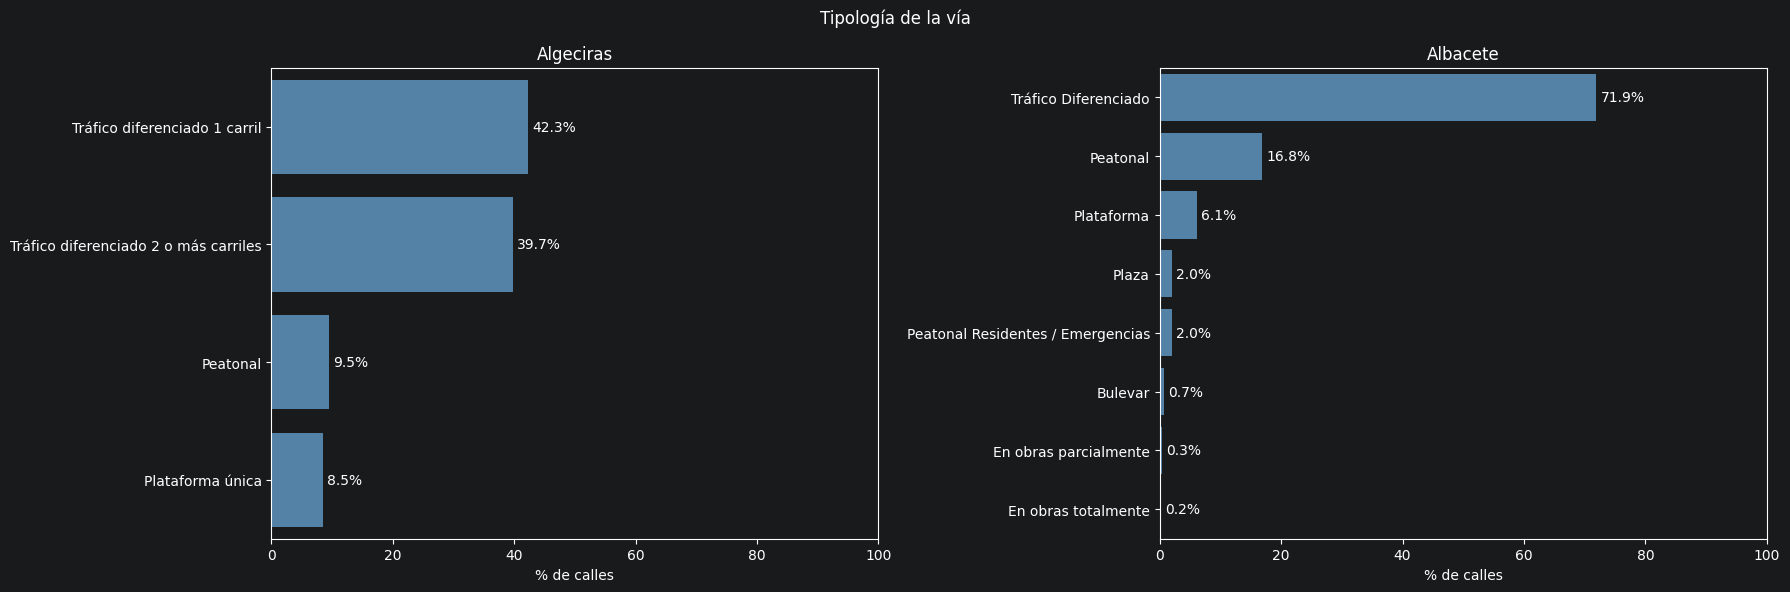

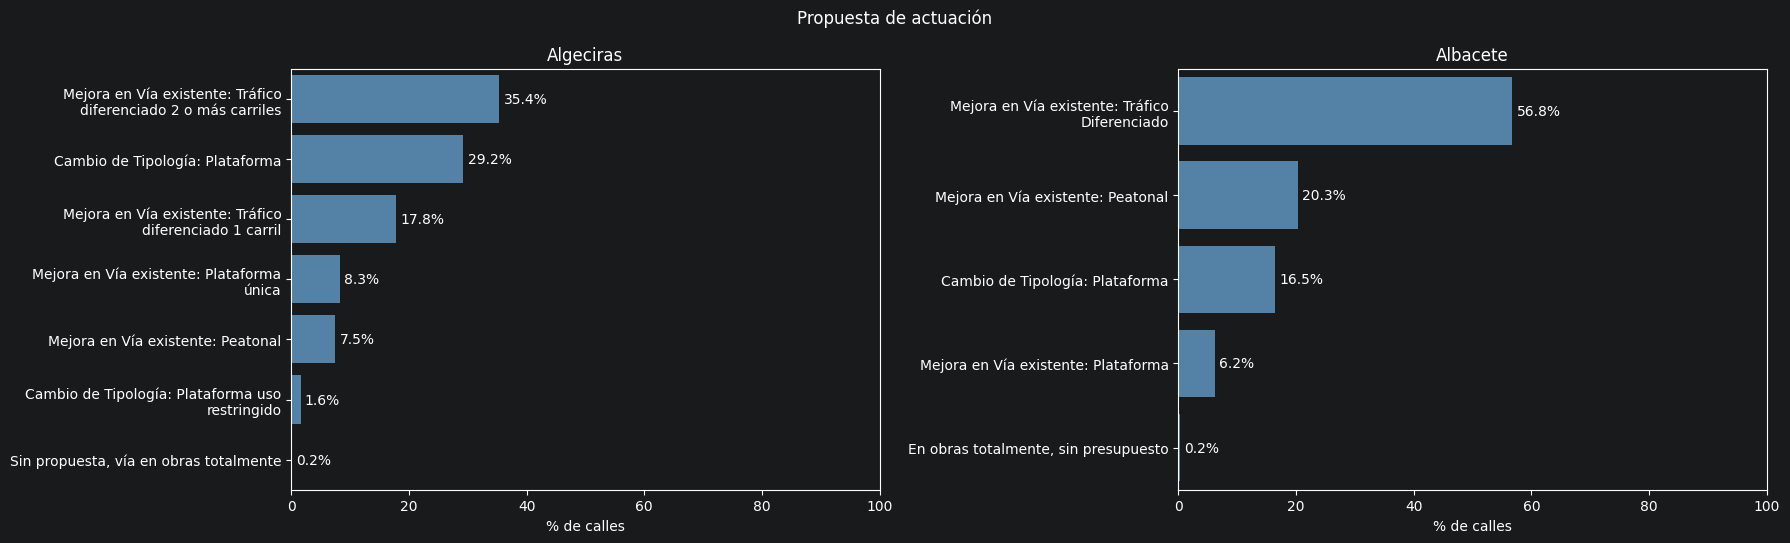

In [5]:
# Percentage of streets of each category of the type of street and the proposal, for each city
for name, (alg_column, alb_column) in {'Tipología de la vía': ('TIPOLOGÍA', 'TIPOLACT'), 'Propuesta de actuación': ('PROPUESTA', 'PROPACT')}.items():
    shares = {'Algeciras': df_alg[alg_column].value_counts(normalize=True) * 100, 'Albacete': df_alb[alb_column].value_counts(normalize=True) * 100}
    fig, axes = plt.subplots(1, 2, figsize=(18, 0.5 * max(len(share) for share in shares.values()) + 2))
    for ax, (city, share) in zip(axes, shares.items()):
        sns.barplot(x=share.values, y=[textwrap.fill(str(label), 38) for label in share.index], orient='h', color='steelblue', ax=ax)
        ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
        ax.set(title=city, xlabel='% de calles', xlim=(0, 100))
    fig.suptitle(name)
    plt.tight_layout()
    plt.show()

En el caso de de vía, las categorías son las mismas, exceptuando:
* En Algeciras, tráfico diferenciado está dividida entre aquellas calles con 1 carril, o 2 o más carriles. En Albacete se recoge todo en una única variable.
* En Albacete hay algunos tipos más: plaza, bulevar, o en obras.

Para el caso de propuesta de actuación, como están los valores compuestos entre la propuesta y el tipo de vía, vamos a mostrar un gráfico agrupando únicamente por propuesta (mejora en vía existente, o cambio de tipología, diferenciando entre plataforma y plataforma única).

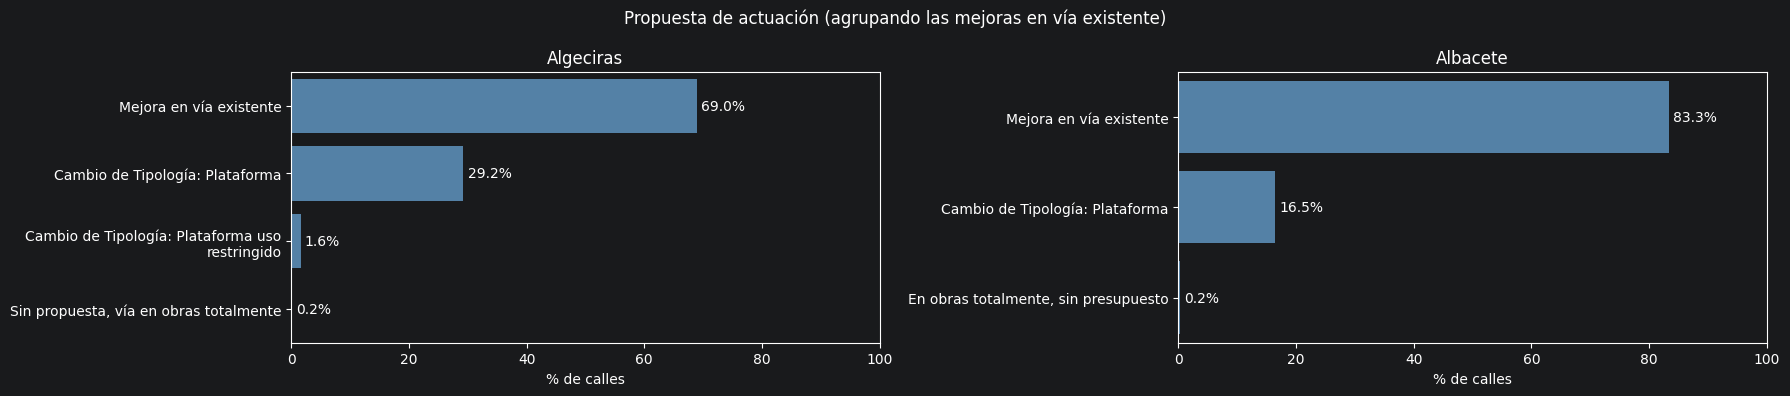

In [6]:
# Show the graph for PROPUESTA and PROPACT transforming the values to set "Mejora en vía existente" for all the values starting with "Mejora en Vía existente"
shares = {
    'Algeciras': df_alg['PROPUESTA'].str.replace(r'^Mejora en Vía existente.*', 'Mejora en vía existente', regex=True).value_counts(normalize=True) * 100,
    'Albacete': df_alb['PROPACT'].str.replace(r'^Mejora en Vía existente.*', 'Mejora en vía existente', regex=True).value_counts(normalize=True) * 100,
}
fig, axes = plt.subplots(1, 2, figsize=(18, 0.5 * max(len(share) for share in shares.values()) + 2))
for ax, (city, share) in zip(axes, shares.items()):
    sns.barplot(x=share.values, y=[textwrap.fill(str(label), 38) for label in share.index], orient='h', color='steelblue', ax=ax)
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    ax.set(title=city, xlabel='% de calles', xlim=(0, 100))
fig.suptitle('Propuesta de actuación (agrupando las mejoras en vía existente)')
plt.tight_layout()
plt.show()

Como se puede comprobar, las columnas de tipo de vía y propuesta muestran la misma información, con pequeñas diferencias.

## Presupuesto
Comparamos el presupuesto (en euros) de las calles de cada ciudad.

In [7]:
# Budget of both datasets
display(pd.DataFrame({'Algeciras': df_alg['PRESUPUESTO'].describe(), 'Albacete': df_alb['PRESUP'].describe()}).round(0))

,Algeciras,Albacete
count,506.0,916.0
mean,146319.0,268468.0
std,184462.0,1094391.0
min,5300.0,0.0
25%,40225.0,55875.0
50%,80900.0,123000.0
75%,169150.0,271000.0
max,1323800.0,31438000.0


Se puede concluir que los presupuestos son diferentes, pero que están en la misma escala (€).

La media de Albacete (146.319 €) es más elevada que la de Algeciras (268.468 €), así como sus medianas (80.900€ frente a 123.000 €).

Tendríamos que comprobar el año en el que se hizo el análisis, las diferencias de precio en cada ciudad...

No obstante ambas columnas se corresponden con el mismo concepto: presupuesto en euros.

## Puntuaciones de accesibilidad
### Escala de las puntuaciones
Comparamos el rango y el número de valores distintos de las columnas de puntuación por dimensión y tipo de diversidad de cada ciudad.

In [8]:
# Scores per dimension and diversity type (without the GLOBAL and TOTAL columns)
alg_scores = df_alg.filter(regex=r'^PUNT_(?!TOTAL)[A-ZÑ]{4}_(FU|SE|CG)$')
alb_scores = df_alb.filter(regex=r'^(PENDIENTE|ANCHURA|PAVIMENTO|CRUCES|SEÑALIZ|ILUMIN|MOBILIAR|TRANSP)(SR|MR|DV|HA|DI)$')

display(pd.DataFrame({
    'Columnas': {'Algeciras': alg_scores.shape[1], 'Albacete': alb_scores.shape[1]},
    'Mínimo': {'Algeciras': alg_scores.min().min(), 'Albacete': alb_scores.min().min()},
    'Máximo': {'Algeciras': alg_scores.max().max(), 'Albacete': alb_scores.max().max()},
    'Valores distintos por columna (mín.)': {'Algeciras': alg_scores.nunique().min(), 'Albacete': alb_scores.nunique().min()},
    'Valores distintos por columna (máx.)': {'Algeciras': alg_scores.nunique().max(), 'Albacete': alb_scores.nunique().max()},
}))

,Columnas,Mínimo,Máximo,Valores distintos por columna (mín.),Valores distintos por columna (máx.)
Algeciras,21,0,5,3,4
Albacete,40,0,100,3,29


Las puntuacione de Albacete oscilan entre 0 y 100, mientras que las puntuaciones de Algeciras están entre 0 y 5.

### Puntuación media por dimensión
Como las escalas son distintas, se comparan las puntuaciones globales de cada dimensión en una escala común de 0 a 100 (las de Algeciras se dividen entre su máximo, 5). Los ceros de TRANSP en Albacete, que indican que no hay datos, no se tienen en cuenta en la media.

,Algeciras,Albacete
Pendiente,58.8,87.7
Anchura,44.2,47.6
Pavimento,40.2,41.3
Cruces,31.6,38.9
Señalización,19.0,29.3
Iluminación,54.1,30.5
Mobiliario,26.7,34.5
Transporte,NaN,33.1


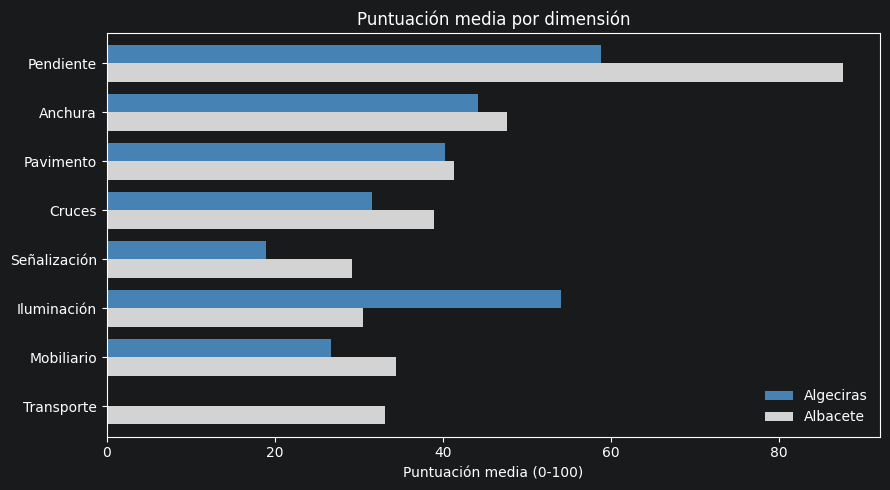

In [9]:
# Mean global score per dimension on a common scale (0-100)
dimension_comparison = pd.DataFrame({
    concept.replace('Puntuación global de ', '').capitalize(): {
        'Algeciras': df_alg[alg_column].mean() / 5 * 100 if alg_column else np.nan,
        'Albacete': df_alb[alb_column].where(df_alb[alb_column] > 0).mean(),  # Only TRANSP has zeros
    }
    for concept, alg_column, alb_column in equivalent_columns if concept.startswith('Puntuación global de ')
}).T
display(dimension_comparison.round(1))

dimension_comparison.plot(kind='barh', figsize=(9, 5), color=['steelblue', 'lightgray'], width=0.75)
plt.gca().invert_yaxis()
plt.xlabel('Puntuación media (0-100)')
plt.title('Puntuación media por dimensión')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Se puede comprobar que los conjuntos de datos, a excepción de transporte, muestran la misma información con diferente escala: la puntuación de accesibilidad sobre cada una de las dimensiones.

Hay diferencias entre las ciudades, pero eso es normal, al ser ciudades diferentes.
Por ejemplo en Pendiente, que es en la que hay más diferencias, es posible a que se deba a que Albacete sea más plana que Algeciras; si no podría ser una diferencia de criterio.

Destaca Algeciras en iluminación, mucho mejor puntuada que Albacete, en el resto de categorías Albacete está algo mejor.

Vamos a comprobar si la distribución es la misma haciendo la transformación de los datos de Albacete a las clases de Algeciras, transformando la escala 0-100 a 0-5 (redondeando).

,Algeciras,Albacete
Pendiente,2.94,4.51
Anchura,2.21,2.46
Pavimento,2.01,2.11
Cruces,1.58,1.98
Señalización,0.95,1.47
Iluminación,2.71,1.48
Mobiliario,1.33,1.70
Transporte,NaN,1.68


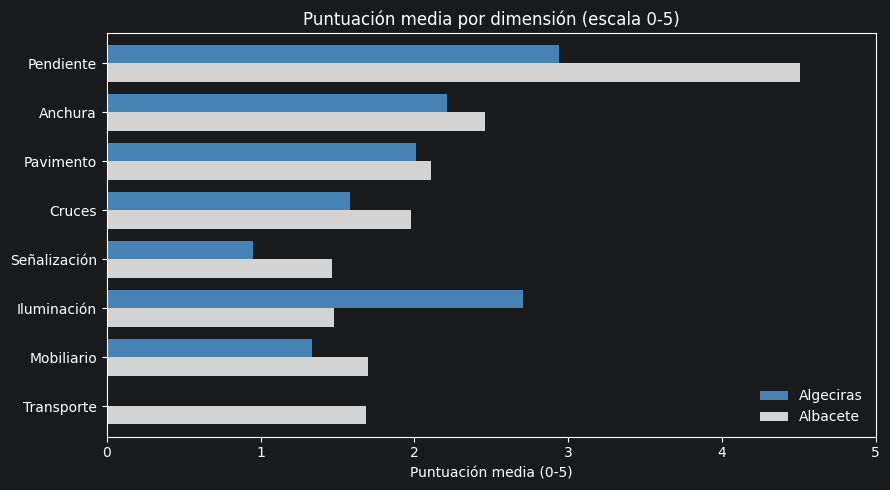

In [10]:
# Mean global score per dimension on a common scale (0-5, rounding the values of Albacete)
dimension_comparison_5 = pd.DataFrame({
    concept.replace('Puntuación global de ', '').capitalize(): {
        'Algeciras': df_alg[alg_column].mean() if alg_column else np.nan,
        'Albacete': np.floor(df_alb[alb_column].where(df_alb[alb_column] > 0) / 20 + 0.5).mean(),  # 0-100 to 0-5, rounding half up (only TRANSP has zeros)
    }
    for concept, alg_column, alb_column in equivalent_columns if concept.startswith('Puntuación global de ')
}).T
display(dimension_comparison_5.round(2))

dimension_comparison_5.plot(kind='barh', figsize=(9, 5), color=['steelblue', 'lightgray'], width=0.75)
plt.gca().invert_yaxis()
plt.xlabel('Puntuación media (0-5)')
plt.xlim(0, 5)
plt.title('Puntuación media por dimensión (escala 0-5)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Comprobamos que al cambiar la escala no hay un cambio significativo, todos los datos son equivalentes.

### Puntuación media por tipo de diversidad
Los tipos de diversidad son distintos en cada ciudad: Algeciras tiene funcional (FU), sensorial (SE) y cognitivo (CG), mientras que Albacete tiene silla de ruedas (SR), movilidad reducida (MR), discapacidad visual (DV), hipoacusia (HA) y cognitiva (DI). Se muestran las puntuaciones medias totales de cada tipo en la escala común de 0 a 100.

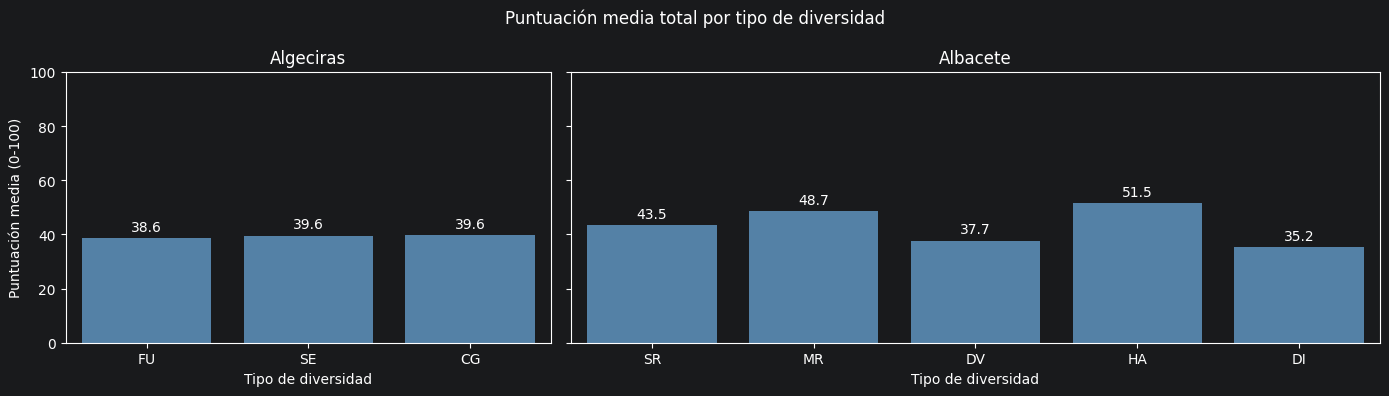

In [11]:
# Mean total score per diversity type on a common scale (0-100)
diversity_scores = {
    'Algeciras': pd.Series({suffix: df_alg[f'PUNT_TOTAL_{suffix}'].mean() for suffix in ['FU', 'SE', 'CG']}) / 5 * 100,
    'Albacete': pd.Series({suffix: df_alb[f'GLOBAL{suffix}'].mean() for suffix in ['SR', 'MR', 'DV', 'HA', 'DI']}),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, gridspec_kw={'width_ratios': [3, 5]})
for ax, (city, scores) in zip(axes, diversity_scores.items()):
    sns.barplot(x=scores.index, y=scores.values, color='steelblue', ax=ax)
    ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
    ax.set(title=city, xlabel='Tipo de diversidad', ylim=(0, 100))
axes[0].set_ylabel('Puntuación media (0-100)')
fig.suptitle('Puntuación media total por tipo de diversidad')
plt.tight_layout()
plt.show()

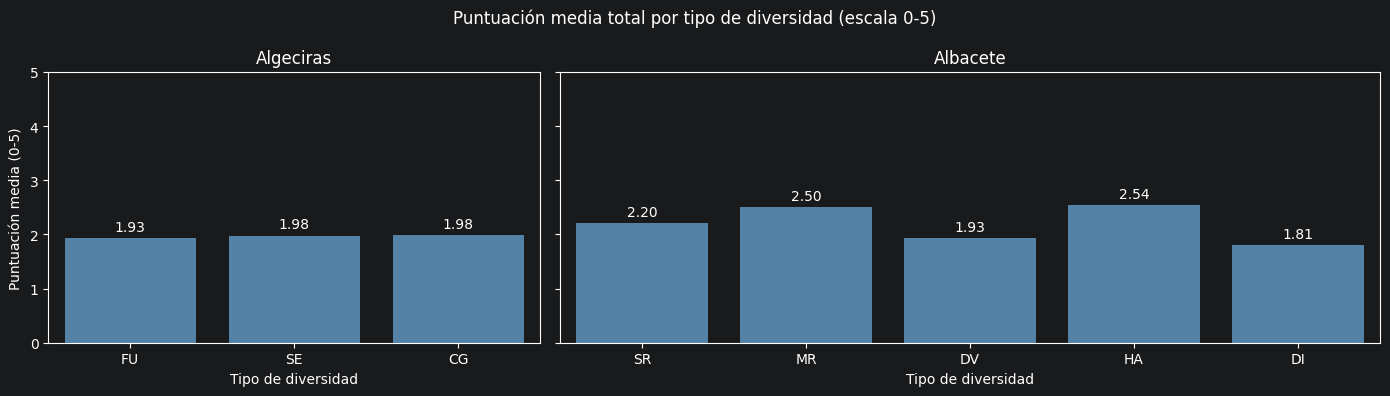

In [12]:
# Mean total score per diversity type on a common scale (0-5)
diversity_scores_5 = {
    'Algeciras': pd.Series({suffix: df_alg[f'PUNT_TOTAL_{suffix}'].mean() for suffix in ['FU', 'SE', 'CG']}),
    'Albacete': pd.Series({suffix: np.floor(df_alb[f'GLOBAL{suffix}'] / 20 + 0.5).mean() for suffix in ['SR', 'MR', 'DV', 'HA', 'DI']}),  # 0-100 to 0-5, rounding half up
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, gridspec_kw={'width_ratios': [3, 5]})
for ax, (city, scores) in zip(axes, diversity_scores_5.items()):
    sns.barplot(x=scores.index, y=scores.values, color='steelblue', ax=ax)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    ax.set(title=city, xlabel='Tipo de diversidad', ylim=(0, 5))
axes[0].set_ylabel('Puntuación media (0-5)')
fig.suptitle('Puntuación media total por tipo de diversidad (escala 0-5)')
plt.tight_layout()
plt.show()

Albacete tiene los datos más detallados, con 5 categorías, pero podemos comparar los valores de las puntuaciones unificando SR con MR para tener FU, y DV con HA para tener SE.

,Algeciras,Albacete
FU,38.6,46.1
SE,39.6,44.6
CG,39.6,35.2


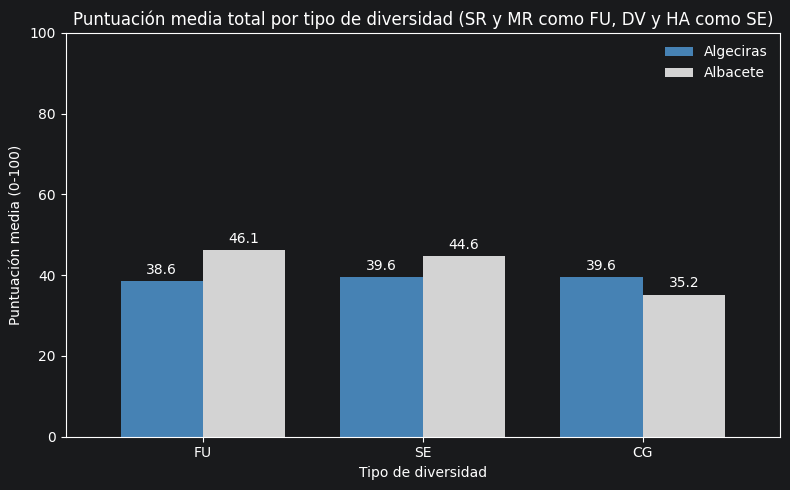

In [13]:
# Mean total score per diversity type on a common scale (0-100), grouping SR and MR as FU, and DV and HA as SE in Albacete
diversity_grouped = pd.DataFrame({
    'Algeciras': pd.Series({suffix: df_alg[f'PUNT_TOTAL_{suffix}'].mean() for suffix in ['FU', 'SE', 'CG']}) / 5 * 100,
    'Albacete': pd.Series({
        'FU': df_alb[['GLOBALSR', 'GLOBALMR']].mean(axis=1).mean(),
        'SE': df_alb[['GLOBALDV', 'GLOBALHA']].mean(axis=1).mean(),
        'CG': df_alb['GLOBALDI'].mean(),
    }),
})
display(diversity_grouped.round(1))

ax = diversity_grouped.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'lightgray'], width=0.75, rot=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
ax.set(xlabel='Tipo de diversidad', ylabel='Puntuación media (0-100)', ylim=(0, 100), title='Puntuación media total por tipo de diversidad (SR y MR como FU, DV y HA como SE)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Se comprueba así que los datos pueden ser completamente comparables, teniendo Albacete mejor puntuación en funcional (46,1% frente a 38,6%), sensorial (44,6% frente a 39,6%); mientras que Algeciras está con notas más altas en cognitiva (39,6% frente a 35,2%).

Las puntuaciones de Albacete son similares en funcional y sensorial pero bajan notoriamente en cognitiva.

Sin embargo, en Algeciras las puntuaciones son muy similares en todos los tipos. Podríamos tener que comprobar si la captura de datos o el algoritmo estaba algo sesgado (SE y CG tienen la misma puntuación exacta).

## Unificación de datos

Vamos a proceder a realizar una unificación de los datos, para poder realizar modelos con las mismas variables.

### Nomenclatura

En primer lugar, se detallan las reglas que se va a seguir a la hora de nombrar las columnas del conjunto unificado:
* Columnas en snake_case (en minúscula y con las palabras separadas por barra baja), y caracteres ASCII (ni tildes, ni eñes).
* Palabras completas, sin utilizar siglas, de manera que las variables sean autodescritivas.
* Se va de lo general a lo específico (qué identifica la variable, qué medida, guarismo... y luego de qué categoría, y subcategoría). Por ejemplo, puntuacion_<dimension>_<diversidad>.
* La misma medida se escribe igual para todas las variables (puntuación siempre será puntuacion, por ejemplo).
* Todas las variables van en singular.
* Solo nombres, sin verbos o artículos.
* Con el fin de aumentar la autodescripción, si una variable puede contener diferentes unidades, se añade la unidad, por ejemplo, presupuesto_euros.
* Los booleanos llevan prefijo es_ (o _tiene).
* Las variables empiezan sin número.
* En caso de tener una variable con nombre muy largo, identificar cómo poder reducirla.

Como reglas generales para los valores:
* En el caso de variables categóricas, se debe utilizar enumerados, en lugar de textos, identificando qué indica cada valor enumerado.




### Columnas unificadas

Siguiendo las reglas anteriores, las dimensiones son `pendiente`, `anchura`, `pavimento`, `cruces`, `senalizacion`, `iluminacion`, `mobiliario` y `transporte` (esta última solo en Albacete), y los tipos de diversidad son `funcional`, `sensorial` y `cognitiva`.

A continuación se muestra cómo quedarían las columnas:

| Concepto | Algeciras | Albacete | Columna unificada |
|---|---|---|---|
| Ciudad (nueva, para unir los datos) | - | - | `ciudad` |
| Nombre de la calle | `NOMBRE` | `NOMBRE` | `nombre_calle` |
| Nombre de la calle sin la marca de tramo | `NOMBRE` sin la marca | `NOMBRE` sin la marca | `nombre_calle_base` |
| Tramo de la calle (número) | Letra de `REFERENCIA` o marca del `NOMBRE` | Número del final de `NOMBRE` | `tramo` |
| Barrio | `Barriada` | - (pendiente de cruzar con el callejero) | `barrio` |
| Zona | - | letras de `REFER` | `zona` |
| Tipología de la vía | `TIPOLOGÍA` | `TIPOLACT` | `tipologia_via` |
| Propuesta de actuación | `PROPUESTA` | `PROPACT` | `propuesta_actuacion` |
| Presupuesto | `PRESUPUESTO` | `PRESUP` | `presupuesto_euros` |
| Puntuación de una dimensión y tipo de diversidad | `PUNT_PEND_FU` | media de `PENDIENTESR` y `PENDIENTEMR` | `puntuacion_pendiente_funcional` |
| Puntuación global de una dimensión | `PUNT_PEND_GB` | `GLOBALPEND` | `puntuacion_pendiente_global` |
| Puntuación total de un tipo de diversidad | `PUNT_TOTAL_FU` | media de `GLOBALSR` y `GLOBALMR` | `puntuacion_total_funcional` |
| Puntuación total | `PUNT_TOTAL` | `ACCGLOBAL` | `puntuacion_total` |
| Clase de accesibilidad total | `PIC_TOTAL` | calculada a partir de `ACCGLOBAL` (ver más abajo) | `clase_total` |

Las columnas `puntuacion_*` siguen el mismo patrón para el resto de dimensiones y tipos de diversidad. Por ejemplo, la señalización cognitiva sería `puntuacion_senalizacion_cognitiva` (`PUNT_SEÑA_CG` en Algeciras y `SEÑALIZDI` en Albacete), y la puntuación global de transporte, `puntuacion_transporte_global` (`GLOBALTRANSP` en Albacete, sin equivalente en Algeciras).

### Clase de accesibilidad

Algeciras tiene una clase de accesibilidad de cada calle (A, B o C, en las columnas PIC_*), que no existe en Albacete, aunque se puede calcular.

Por lo analizado en el notebook 0.01 de Algeciras, parece que las clases salen de dividir las puntuaciones en 1/3 y 2/3 de la puntuación máxima (5): C por debajo de un tercio, B entre un tercio y dos tercios, y A a partir de dos tercios.

Podemos calcular la clase de Albacete con los mismos cortes sobre su escala de 0 a 100 (C por debajo de 33,3, B entre 33,3 y 66,7, y A a partir de 66,7), a partir de `ACCGLOBAL`.

Comparamos el porcentaje de calles de cada clase en las dos ciudades.

In [14]:
# Class of a score: C below 1/3 of the maximum score, B between 1/3 and 2/3, and A from 2/3
def class_by_thirds(score, maximum):
    return pd.Series(np.where(score < maximum / 3, 'C', np.where(score < 2 * maximum / 3, 'B', 'A')), index=score.index)

In [15]:
# Class of the total score of Albacete, using the same cut points on the 0-100 scale, compared with the class of Algeciras
class_albacete = class_by_thirds(df_alb['ACCGLOBAL'], 100)
display(pd.DataFrame({
    'Algeciras': df_alg['PIC_TOTAL'].value_counts(normalize=True) * 100,
    'Albacete': class_albacete.value_counts(normalize=True) * 100,
}).loc[['A', 'B', 'C']].round(1))

,Algeciras,Albacete
A,5.5,2.6
B,56.1,78.2
C,38.3,19.2


### Escala de las puntuaciones

Las puntuaciones de Algeciras van de 0 a 5, y las de Albacete de 0 a 100. Para unificarlas, se normalizan a la escala de 0 a 1 (por ser un estándar en la ciencia de datos), dividiendo cada puntuación entre el máximo de su escala (5 en Algeciras y 100 en Albacete).

Se divide entre el máximo de la escala, y no entre el máximo de los datos (normalización min-max), para que el resultado no dependa de la muestra y las dos ciudades sigan siendo comparables. Se trabaja con copias de los datos, para no modificar los originales.

In [16]:
# Scale the scores to the range 0-1, dividing by the maximum of each scale (5 in Algeciras and 100 in Albacete), in copies of the datasets
alg_score_columns = [col for col in df_alg.columns if col.startswith('PUNT_')]
alb_score_columns = ['ACCGLOBAL'] + [col for col in df_alb.columns if col.startswith('GLOBAL')] + list(alb_scores.columns)

df_alg_scaled = df_alg.copy()
df_alg_scaled[alg_score_columns] = df_alg[alg_score_columns] / 5
df_alb_scaled = df_alb.copy()
df_alb_scaled[alb_score_columns] = df_alb[alb_score_columns] / 100

# Check the range of the scaled scores
scaled_range = pd.DataFrame({
    'Columnas': {'Algeciras': len(alg_score_columns), 'Albacete': len(alb_score_columns)},
    'Mínimo': {'Algeciras': df_alg_scaled[alg_score_columns].min().min(), 'Albacete': df_alb_scaled[alb_score_columns].min().min()},
    'Máximo': {'Algeciras': df_alg_scaled[alg_score_columns].max().max(), 'Albacete': df_alb_scaled[alb_score_columns].max().max()},
})
display(scaled_range)
assert (scaled_range['Mínimo'] >= 0).all() and (scaled_range['Máximo'] <= 1).all()

,Columnas,Mínimo,Máximo
Algeciras,32,0.0,1.0
Albacete,54,0.0,1.0


### Creación del conjunto de datos unificado

Una vez definidas las reglas de nomenclatura, la escala y la variable de clase, se crea el conjunto de datos unificado, que tiene las mismas columnas para las dos ciudades, con una armonización de los valores, para que puedan compararse. Como resumen:
* Se utilizan las puntuaciones normalizadas a la escala de 0 a 1.
* En Albacete se agrupan los tipos de diversidad: funcional es la media de silla de ruedas SR y movilidad reducida MR, sensorial es la media de visual DV e hipoacusia HA, y cognitiva es DI.
* En Albacete, los ceros de transporte indican que no hay datos, por lo que se sustituyen por valores nulos. Transporte no existe en Algeciras (nulo), el barrio solo existe en Algeciras (nulo en Albacete, a la espera de poder cruzar los datos con el callejero para obtenerlo), y la zona (las letras de REFER) solo existe en Albacete (nula en Algeciras). Por el momento se mantienen las variables, por si pueden aportar información útil.
* Se añade el nombre base de la calle (sin la marca de tramo) y el tramo (como número, nulo si la calle no tiene marca), para identificar las calles que están divididas en tramos.
* La clase total es `PIC_TOTAL` en Algeciras, y se calcula en Albacete con el mismo algoritmo.
* Se descartan las columnas FASE, REFER y NUM_CALLE, y todas las clases PIC_* excepto la total.

Primero se definen las correspondencias de nombres entre las dimensiones y los tipos de diversidad.

In [17]:
# Correspondence between the dimensions and diversity types of both cities and the names of the unified dataset
unified_dimensions = {  # unified name: (Algeciras code, Albacete prefix, Albacete global column)
    'pendiente': ('PEND', 'PENDIENTE', 'GLOBALPEND'),
    'anchura': ('ANCH', 'ANCHURA', 'GLOBALANCH'),
    'pavimento': ('PAVI', 'PAVIMENTO', 'GLOBALPAVIM'),
    'cruces': ('CRUC', 'CRUCES', 'GLOBALCRUCES'),
    'senalizacion': ('SEÑA', 'SEÑALIZ', 'GLOBALSEÑAL'),
    'iluminacion': ('ILUM', 'ILUMIN', 'GLOBALILUM'),
    'mobiliario': ('MOBI', 'MOBILIAR', 'GLOBALMOBI'),
    'transporte': (None, 'TRANSP', 'GLOBALTRANSP'),  # Only in Albacete
}
unified_diversity_types = {  # unified name: (Algeciras suffix, Albacete suffixes that are averaged)
    'funcional': ('FU', ['SR', 'MR']),
    'sensorial': ('SE', ['DV', 'HA']),
    'cognitiva': ('CG', ['DI']),
}

A continuación se crean las columnas unificadas de cada ciudad, siguiendo las reglas de nomenclatura: ciudad, datos de la calle, puntuación total, y puntuaciones de cada dimensión.

In [18]:
# Unified columns of Algeciras (scores already scaled to 0-1, in df_alg_scaled)
alg_data = {
    'ciudad': 'Algeciras',
    'nombre_calle': df_alg_scaled['NOMBRE'],
    'nombre_calle_base': df_alg_scaled['NOMBRE_BASE'],
    'tramo': df_alg_scaled['TRAMO'].astype('Int64'),
    'barrio': df_alg_scaled['Barriada'],
    'zona': np.nan,  # Only in Albacete
    'tipologia_via': df_alg_scaled['TIPOLOGÍA'],
    'propuesta_actuacion': df_alg_scaled['PROPUESTA'],
    'presupuesto_euros': df_alg_scaled['PRESUPUESTO'],
    'puntuacion_total': df_alg_scaled['PUNT_TOTAL'],
}
for diversity, (alg_suffix, _) in unified_diversity_types.items():
    alg_data[f'puntuacion_total_{diversity}'] = df_alg_scaled[f'PUNT_TOTAL_{alg_suffix}']
for dimension, (alg_code, _, _) in unified_dimensions.items():
    alg_data[f'puntuacion_{dimension}_global'] = df_alg_scaled[f'PUNT_{alg_code}_GB'] if alg_code else np.nan
    for diversity, (alg_suffix, _) in unified_diversity_types.items():
        alg_data[f'puntuacion_{dimension}_{diversity}'] = df_alg_scaled[f'PUNT_{alg_code}_{alg_suffix}'] if alg_code else np.nan
alg_data['clase_total'] = df_alg_scaled['PIC_TOTAL']
unified_alg = pd.DataFrame(alg_data)

In [19]:
# Unified columns of Albacete (scores already scaled to 0-1, in df_alb_scaled)
# The zeros of TRANSP mean that there is no data, so they are replaced by null values
alb_scaled = df_alb_scaled.copy()
transport_columns = [col for col in alb_scaled.columns if col.startswith('TRANSP') or col == 'GLOBALTRANSP']
alb_scaled[transport_columns] = alb_scaled[transport_columns].replace(0, np.nan)

alb_data = {
    'ciudad': 'Albacete',
    'nombre_calle': alb_scaled['NOMBRE'],
    'nombre_calle_base': alb_scaled['NOMBRE_BASE'],
    'tramo': alb_scaled['TRAMO'].astype('Int64'),
    'barrio': np.nan,  # Only in Algeciras, until the data can be crossed with the street map
    'zona': alb_scaled['ZONA'],  # Letters of REFER
    'tipologia_via': alb_scaled['TIPOLACT'],
    'propuesta_actuacion': alb_scaled['PROPACT'],
    'presupuesto_euros': alb_scaled['PRESUP'],
    'puntuacion_total': alb_scaled['ACCGLOBAL'],
}
for diversity, (_, alb_suffixes) in unified_diversity_types.items():
    alb_data[f'puntuacion_total_{diversity}'] = alb_scaled[[f'GLOBAL{suffix}' for suffix in alb_suffixes]].mean(axis=1)
for dimension, (_, alb_prefix, alb_global) in unified_dimensions.items():
    alb_data[f'puntuacion_{dimension}_global'] = alb_scaled[alb_global]
    for diversity, (_, alb_suffixes) in unified_diversity_types.items():
        alb_data[f'puntuacion_{dimension}_{diversity}'] = alb_scaled[[f'{alb_prefix}{suffix}' for suffix in alb_suffixes]].mean(axis=1)
alb_data['clase_total'] = class_by_thirds(df_alb['ACCGLOBAL'], 100)  # Calculated with the cut points of Algeciras
unified_alb = pd.DataFrame(alb_data)

#### Propuesta de actuación

La propuesta de actuación mezcla dos informaciones: el tipo de propuesta (mejora en vía existente, cambio de tipología o sin propuesta) y el tipo de vía. En las mejoras en vía existente, el tipo de vía de la propuesta coincide con el de la tipología de la calle, por lo que no aporta información nueva.

Por tanto, se deja solo el tipo de propuesta, con los valores `mejora_via_existente`, `cambio_tipologia` y `sin_propuesta` (calles en obras, sin propuesta).

La columna `cambio_tipologia` podría tener valores diferenciados para indicar cuál es la tipología que se propone, por el momento se deja como categoría única, por armonizar valores entre conjuntos.

Se muestra la correspondencia entre los valores originales y los unificados.

In [20]:
# Kind of proposal (without the type of street) of the original proposals
def proposal_kind(proposal):
    lower = proposal.str.lower()
    return pd.Series(np.select(
        [lower.str.startswith('mejora'), lower.str.startswith('cambio'), lower.str.startswith(('sin', 'en obras'))],
        ['mejora_via_existente', 'cambio_tipologia', 'sin_propuesta'], default='desconocida'), index=proposal.index)

kind_alg = proposal_kind(unified_alg['propuesta_actuacion'])
kind_alb = proposal_kind(unified_alb['propuesta_actuacion'])
assert not (kind_alg == 'desconocida').any() and not (kind_alb == 'desconocida').any()

display(pd.concat([
    pd.DataFrame({'ciudad': 'Algeciras', 'propuesta original': unified_alg['propuesta_actuacion'], 'propuesta unificada': kind_alg}),
    pd.DataFrame({'ciudad': 'Albacete', 'propuesta original': unified_alb['propuesta_actuacion'], 'propuesta unificada': kind_alb}),
]).groupby(['ciudad', 'propuesta unificada', 'propuesta original']).size().reset_index(name='calles'))

,ciudad,propuesta unificada,propuesta original,calles
0,Albacete,cambio_tipologia,Cambio de Tipología: Plataforma,151
1,Albacete,mejora_via_existente,Mejora en Vía existente: Peatonal,186
2,Albacete,mejora_via_existente,Mejora en Vía existente: Plataforma,57
3,Albacete,mejora_via_existente,Mejora en Vía existente: Tráfico Diferenciado,520
4,Albacete,sin_propuesta,"En obras totalmente, sin presupuesto",2
5,Algeciras,cambio_tipologia,Cambio de Tipología: Plataforma,148
6,Algeciras,cambio_tipologia,Cambio de Tipología: Plataforma uso restringido,8
7,Algeciras,mejora_via_existente,Mejora en Vía existente: Peatonal,38
8,Algeciras,mejora_via_existente,Mejora en Vía existente: Plataforma única,42
9,Algeciras,mejora_via_existente,Mejora en Vía existente: Tráfico diferenciado ...,90


In [21]:
# Keep only the kind of proposal in the unified columns
unified_alg['propuesta_actuacion'] = kind_alg
unified_alb['propuesta_actuacion'] = kind_alb

display(pd.DataFrame({
    'Algeciras': unified_alg['propuesta_actuacion'].value_counts(normalize=True) * 100,
    'Albacete': unified_alb['propuesta_actuacion'].value_counts(normalize=True) * 100,
}).round(1))

,Algeciras,Albacete
propuesta_actuacion,,
mejora_via_existente,69.0,83.3
cambio_tipologia,30.8,16.5
sin_propuesta,0.2,0.2


#### Tipología de la vía

Para armonizar la tipología de la vía se usan las siguientes reglas:
* `trafico_diferenciado`: se unen las categorías de tráfico diferenciado de Algeciras (1 carril, y 2 o más carriles), para que coincidan con la de Albacete, que no distingue el número de carriles. Es una forma de tener la misma categoría en las dos ciudades, aunque Algeciras pierde nivel de detalle (se puede evaluar en el futuro si añadir la separación en una columna si es necesario).
* `peatonal`: peatonal en las dos ciudades, y peatonal de residentes o emergencias en Albacete.
* `plataforma`: plataforma única en Algeciras, y plataforma en Albacete.
* `plaza` y `bulevar`: solo existen en Albacete, y se mantienen como categorías propias.
* `en_obras`: las calles en obras (parcialmente o totalmente) de Albacete.

Se muestra la correspondencia entre los valores originales y los unificados.

In [22]:
# Unified type of street of the original values (the unified values are also included, so the cell can be run again)
street_type_mapping = {
    'tráfico diferenciado 1 carril': 'trafico_diferenciado',
    'tráfico diferenciado 2 o más carriles': 'trafico_diferenciado',
    'tráfico diferenciado': 'trafico_diferenciado',
    'peatonal': 'peatonal',
    'peatonal residentes / emergencias': 'peatonal',
    'plataforma única': 'plataforma',
    'plataforma': 'plataforma',
    'plaza': 'plaza',
    'bulevar': 'bulevar',
    'en obras parcialmente': 'en_obras',
    'en obras totalmente': 'en_obras',
}
street_type_mapping.update({value: value for value in set(street_type_mapping.values())})

street_type_alg = unified_alg['tipologia_via'].str.lower().map(street_type_mapping)
street_type_alb = unified_alb['tipologia_via'].str.lower().map(street_type_mapping)
assert not street_type_alg.isnull().any() and not street_type_alb.isnull().any()

display(pd.concat([
    pd.DataFrame({'ciudad': 'Algeciras', 'tipología original': unified_alg['tipologia_via'], 'tipología unificada': street_type_alg}),
    pd.DataFrame({'ciudad': 'Albacete', 'tipología original': unified_alb['tipologia_via'], 'tipología unificada': street_type_alb}),
]).groupby(['ciudad', 'tipología unificada', 'tipología original']).size().reset_index(name='calles'))

,ciudad,tipología unificada,tipología original,calles
0,Albacete,bulevar,Bulevar,6
1,Albacete,en_obras,En obras parcialmente,3
2,Albacete,en_obras,En obras totalmente,2
3,Albacete,peatonal,Peatonal,154
4,Albacete,peatonal,Peatonal Residentes / Emergencias,18
5,Albacete,plataforma,Plataforma,56
6,Albacete,plaza,Plaza,18
7,Albacete,trafico_diferenciado,Tráfico Diferenciado,659
8,Algeciras,peatonal,Peatonal,48
9,Algeciras,plataforma,Plataforma única,43


In [23]:
# Keep the unified type of street in the unified columns
unified_alg['tipologia_via'] = street_type_alg
unified_alb['tipologia_via'] = street_type_alb

display(pd.DataFrame({
    'Algeciras': unified_alg['tipologia_via'].value_counts(normalize=True) * 100,
    'Albacete': unified_alb['tipologia_via'].value_counts(normalize=True) * 100,
}).fillna(0).round(1))

,Algeciras,Albacete
tipologia_via,,
bulevar,0.0,0.7
en_obras,0.0,0.5
peatonal,9.5,18.8
plataforma,8.5,6.1
plaza,0.0,2.0
trafico_diferenciado,82.0,71.9


Se unen los datos de las dos ciudades, y se comprueba que las columnas cumplen las reglas de nomenclatura (snake_case, ASCII, menos de 40 caracteres y sin empezar por número) y que las puntuaciones están entre 0 y 1.

In [24]:
# Unified dataset, and check of the naming rules and the scale
df_unified = pd.concat([unified_alg, unified_alb], ignore_index=True)

assert df_unified.columns.is_unique
assert all(re.fullmatch(r'[a-z][a-z0-9_]*', col) and len(col) < 40 for col in df_unified.columns)  # snake_case, ASCII, short, and not starting with a number
score_columns_unified = [col for col in df_unified.columns if col.startswith('puntuacion_')]
assert df_unified[score_columns_unified].stack().between(0, 1).all()

print(f"Filas: {len(df_unified)}, columnas: {df_unified.shape[1]}")
display(df_unified.groupby('ciudad').size().to_frame('calles'))
display(df_unified.isnull().sum().loc[lambda nulls: nulls > 0].to_frame('valores nulos'))
display(df_unified.head())

Filas: 1422, columnas: 46


,calles
ciudad,
Albacete,916
Algeciras,506


,valores nulos
tramo,1056
barrio,916
zona,506
puntuacion_transporte_global,829
puntuacion_transporte_funcional,829
puntuacion_transporte_sensorial,829
puntuacion_transporte_cognitiva,829


,ciudad,nombre_calle,nombre_calle_base,tramo,barrio,zona,tipologia_via,propuesta_actuacion,presupuesto_euros,puntuacion_total,...,puntuacion_iluminacion_cognitiva,puntuacion_mobiliario_global,puntuacion_mobiliario_funcional,puntuacion_mobiliario_sensorial,puntuacion_mobiliario_cognitiva,puntuacion_transporte_global,puntuacion_transporte_funcional,puntuacion_transporte_sensorial,puntuacion_transporte_cognitiva,clase_total
0,Algeciras,Calle Juan Pérez Arriete,CALLE JUAN PEREZ ARRIETE,<NA>,El Rosario,NaN,trafico_diferenciado,mejora_via_existente,321300,0.742857,...,1.0,0.533333,0.4,0.6,0.6,NaN,NaN,NaN,NaN,A
1,Algeciras,Avenida Virgen del Carmen,AVENIDA VIRGEN DEL CARMEN,<NA>,La Reconquista,NaN,trafico_diferenciado,mejora_via_existente,967900,0.742857,...,1.0,0.533333,0.4,0.6,0.6,NaN,NaN,NaN,NaN,A
2,Algeciras,Paseo De la Conferencia 1,PASEO DE LA CONFERENCIA,1,Puerto,NaN,trafico_diferenciado,mejora_via_existente,141400,0.742857,...,1.0,0.533333,0.4,0.6,0.6,NaN,NaN,NaN,NaN,A
3,Algeciras,Paseo De la Conferencia,PASEO DE LA CONFERENCIA,2,La Banda del Río,NaN,trafico_diferenciado,mejora_via_existente,276900,0.180952,...,0.4,0.200000,0.2,0.2,0.2,NaN,NaN,NaN,NaN,C
4,Algeciras,Calle Carteya,CALLE CARTEYA,<NA>,La Caridad,NaN,trafico_diferenciado,mejora_via_existente,77200,0.400000,...,0.4,0.200000,0.2,0.2,0.2,NaN,NaN,NaN,NaN,B


Finalmente, se guarda el conjunto de datos unificado en la carpeta de datos procesados.

In [25]:
# Save the unified dataset in the data/processed
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
df_unified.to_csv(PROCESSED_DATA_DIR / "streets_unified.csv", index=False)